# Cap. 14.5 — Componentes principales (PCA)

📕 ESL §14.5.1 *Principal Components* (cap. 14, *Unsupervised Learning*); apoyos: §3.4.1 y §3.5.1 · 📘 *Mathematics for Machine Learning*, cap. 10 · 🔗 clase 3 (SVD), clase 4 (ridge), clase 6 §5 (espectral y esferizar)

Notación: la de ESL. $\mathbf{X}$ es la matriz $N\times p$ **ya centrada** (en el código de los países, además estandarizada: se llama `Z`), $\mathbf{X}=\mathbf{U}\mathbf{D}\mathbf{V}^T$ es su SVD (la de la clase 3, con $d_j$ los **valores singulares**), y $v_j$ son las columnas de $\mathbf{V}$. La letra $\lambda$ tiene tres usos que se mantienen separados: $\hat\lambda_i$ = coordenadas de un punto (§1), $\lambda_j=d_j^2/N$ = varianza de un componente (§2), y $\lambda$ = penalidad de ridge (§7).

> ⚠️ **Este tema no está cubierto en ninguna notebook del repo todavía** (hay menciones sueltas: clase 3 §4, clase 6 §5, `notes/descomposicion-matrices-svd.md` §3.6). Lo que sale de ESL está anclado a §14.5.1 / §3.4.1. Lo que sale de *Mathematics for Machine Learning* o de conocimiento general lo marco con **(MML / general)** para que lo contrastes con el libro y con las slides del profe.

> **TL;DR**
>
> - PCA busca el **mejor subespacio de dimensión $q$** para aproximar la nube de puntos: el que minimiza el error de reconstrucción (distancia perpendicular de cada punto al subespacio).
> - Por Pitágoras, minimizar lo que perdés equivale a **maximizar la varianza de lo que conservás**. Por eso "componentes ordenados por varianza".
> - La solución **es la SVD** de $\mathbf{X}$ centrada: direcciones $=$ columnas de $\mathbf{V}$, coordenadas (*scores*) $=\mathbf{U}\mathbf{D}=\mathbf{X}\mathbf{V}$, varianza del componente $j$ $=d_j^2/N$.
> - PCA **no es invariante a la escala**: si no estandarizás, gana la variable con unidades grandes. En los países europeos, sin estandarizar, el PC1 es *casi solo* el área (99 % de la varianza).
> - PCA es **no supervisado** (nunca mira una $y$). El enunciado del TP lo presenta como "supervised dimensionality reduction bridge"; es, en realidad, el puente *hacia* el no supervisado (el lugar donde sí aparece junto a una $y$ es §7).

## 🗺️ Mapa y plan de estudio (≈ 10 h)

| § | Tema | Idea central | Tiempo |
|---|---|---|---|
| 0 | Los datos: 28 países | las escalas son incomparables → ejemplo corriente | 0,5 h |
| 1 | PCA como aproximación | mejor subespacio afín; derivar $\hat\mu$ y $\hat\lambda_i$ | 1 h |
| 2 | La solución es la SVD | Pitágoras, varianza $d_j^2/N$, SVD $\equiv$ eigen de la covarianza | 2 h |
| 3 | Centrar y estandarizar | PCA no es invariante (contraste con LDA) | 1 h |
| 4 | PCA a mano vs scikit-learn | el núcleo del TP | 1,5 h |
| 5 | Leer el resultado | scree, loadings, biplot | 1 h |
| 6 | Proyectar países nuevos | `transform`, score extremo vs error de reconstrucción | 1 h |
| 7 | PCA dentro de ridge (opcional) | puente con la clase 4 (§3.4.1) | 0,25 h |
| 8 | Checklist del TP y guion de 5 min | | 0,25 h |
| ✅ | Autoevaluación | hacerla a mano antes de abrir la respuesta | 1,5 h |

> 📝 **Cómo usar este notebook.** Es material de **estudio**: el TP lo escribe tu grupo, con su propio código, orden y figuras. Una buena práctica: tapá cada celda de §4 y escribí la función de memoria antes de mirarla.

*No entra:* Procrustes (el resto de §14.5.1), curvas y superficies principales (§14.5.2), kernel PCA, sparse PCA.

In [1]:
# Setup
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.frameon": False,
})
np.set_printoptions(precision=3, suppress=True)

## 0. Los datos: 28 países europeos

📕 contexto: ESL §14.5 (la sección arranca de $N$ puntos $x_i\in\mathbb{R}^p$)

El CSV está en `src/datasets/paises_europa.csv`. **De dónde salió:** de dos repos públicos de GitHub que lo comparten (mismas 28 filas, comparadas con `diff`), no de la cátedra. Las unidades **no vienen en el archivo**; las que figuran abajo son inferidas. **Compará con el CSV que les den**: si difiere, cambiá solo el archivo; el notebook no depende de los valores.

| Columna | Unidad (inferida) |
|---|---|
| `Area` | km² |
| `GDP` | PIB per cápita, USD (PPP) |
| `Inflation`, `Pop.growth`, `Unemployment` | % anual |
| `Life.expect` | años |
| `Military` | gasto militar, % del PIB (la consigna lo llama "índice de desarrollo militar"; por los valores — Islandia $0$ — es gasto) |

Este es **el ejemplo corriente de todo el notebook**: $N=28$ países, $p=7$ variables.

In [2]:
paises = pd.read_csv("../../src/datasets/paises_europa.csv", index_col="Country")
X_raw = paises.to_numpy(dtype=float)
N, p = X_raw.shape
print(f"N = {N} países, p = {p} variables")
paises.describe().loc[["mean", "std", "min", "max"]].round(2).T

N = 28 países, p = 7 variables


,mean,std,min,max
Area,166422.54,165538.68,2586.00,603550.00
GDP,31860.71,14502.12,7200.00,80600.00
Inflation,3.34,1.40,0.20,8.00
Life.expect,78.12,3.19,68.74,81.86
Military,1.61,0.80,0.00,4.30
Pop.growth,0.12,0.50,-0.80,1.14
Unemployment,9.92,4.68,2.80,21.70


Mirá la columna `std`: el área tiene un desvío de $\approx 165\,000$ (km²) y la inflación de $\approx 1{,}4$ (%). **No son magnitudes comparables**, y PCA va a tratar esa diferencia como si fuera información. Todo el §3 gira alrededor de eso (adelanto: sin estandarizar, el PC1 de estos países es $99\,\%$ el área).

Preguntas que guían el resto: *¿hay un "plano" de 2 dimensiones donde estos 28 países se vean casi como son en 7? ¿Qué variables arman ese plano? ¿Dónde caería un país que no está en la tabla?*

## 1. PCA como mejor aproximación lineal

📕 ESL §14.5.1 · 📘 MML cap. 10 **(MML / general)** para la versión "máxima varianza"

> **Pregunta guía:** si tengo que describir cada país con $q<p$ números en vez de $p$, ¿qué $q$ números elijo para perder lo menos posible?

#### La idea en criollo

Imaginate que tenés que fotografiar una escultura con forma de cigarro y no podés sacar más que una foto plana. Si la fotografiás **de punta**, ves un círculo y perdiste el largo, que era casi toda la información. Si la fotografiás **de costado**, ves el cigarro entero. PCA es elegir el ángulo de cámara que menos distorsiona, y lo hace con la cámara "ortográfica": cada punto de la escultura cae perpendicular sobre la foto.

> **Dónde se rompe la analogía.** Una foto real tiene perspectiva (lo lejano se achica); acá la proyección es ortogonal pura, como un plano de arquitecto. Y la "foto" de PCA no tiene por qué ser 2D: puede ser de $q$ dimensiones, para cualquier $q\le p$. Tampoco elige el ángulo "más interesante", sino el que **más varianza conserva**; si lo interesante está en una dirección de poca varianza, PCA lo tira.

#### Formalizándolo

ESL representa cada observación con un modelo lineal de rango $q$:

$$f(\lambda)=\mu+\mathbf{V}_q\lambda \tag{14.49}$$

con $\mu\in\mathbb{R}^p$ (un punto de apoyo), $\mathbf{V}_q$ una matriz $p\times q$ con columnas **ortonormales** (las direcciones) y $\lambda\in\mathbb{R}^q$ (las coordenadas; no es el autovalor ni la penalidad de ridge). Es la ecuación de un plano que no pasa necesariamente por el origen. Se ajusta por mínimos cuadrados, o sea minimizando el **error de reconstrucción**:

$$\min_{\mu,\{\lambda_i\},\mathbf{V}_q}\ \sum_{i=1}^{N}\|x_i-\mu-\mathbf{V}_q\lambda_i\|^2 \tag{14.50}$$

**Paso 1: optimizar las coordenadas $\lambda_i$** (con $\mu$ y $\mathbf{V}_q$ fijos). Cada $i$ aparece en un solo sumando, así que se resuelven por separado. Derivamos respecto de $\lambda_i$ e igualamos a cero:

$$\frac{\partial}{\partial\lambda_i}\|x_i-\mu-\mathbf{V}_q\lambda_i\|^2=-2\mathbf{V}_q^T(x_i-\mu-\mathbf{V}_q\lambda_i)=0 .$$

Como las columnas son ortonormales, $\mathbf{V}_q^T\mathbf{V}_q=I_q$ y queda

$$\hat\lambda_i=\mathbf{V}_q^T(x_i-\mu)\qquad\text{(con }\mu=\bar x\text{ es la ec. 14.52)}$$

Es decir: la coordenada óptima es **la proyección ortogonal** de $x_i-\mu$ sobre cada dirección. (Es la ecuación normal de la clase 2, con una matriz de diseño de columnas ortonormales: $(\mathbf{V}^T\mathbf{V})^{-1}=I$ y no hay nada que invertir.)

**Paso 2: optimizar $\mu$.** Con $H_q=\mathbf{V}_q\mathbf{V}_q^T$ (la matriz de proyección sobre el plano), el residuo de cada punto es $(I-H_q)(x_i-\mu)$. Derivando la suma respecto de $\mu$:

$$-2\sum_i (I-H_q)(x_i-\mu)=0\ \Longrightarrow\ (I-H_q)(\bar x-\mu)=0 .$$

$\mu=\bar x$ lo cumple, y ESL lo toma como solución ($\hat\mu=\bar x$, ec. 14.51). Un matiz que ESL no dice: la ecuación solo exige que $\bar x-\mu$ esté **dentro del plano** (ahí $(I-H_q)$ lo anula), así que $\mu$ está determinado solo hasta moverlo dentro del plano. Mismo plano, otro punto de apoyo; la elección natural es el centroide.

**Consecuencia:** el plano pasa por el centroide $\bar x$. Por eso centramos: de ahora en adelante $x_i\leftarrow x_i-\bar x$ y el problema que queda es

$$\min_{\mathbf{V}_q}\ \sum_{i=1}^{N}\|x_i-\mathbf{V}_q\mathbf{V}_q^Tx_i\|^2 \tag{14.53}$$

#### ¿Por qué nos importa?

Porque convierte un problema de **estadística descriptiva** ("las direcciones de máxima varianza") en uno de **aproximación**: quedarte con $q$ números por observación con el menor error posible. Es la misma lógica de compresión de la clase 3, y es lo que justifica usar PCA para visualizar, para comprimir o para sacar ruido.

#### En código: el caso más chico posible ($p=2$)

Con dos variables estandarizadas (`GDP` y `Life.expect`) se puede **ver** qué optimiza (14.53). Para cada ángulo $\theta$ de la recta por el origen calculo dos cosas: el error de reconstrucción y la varianza de las proyecciones.

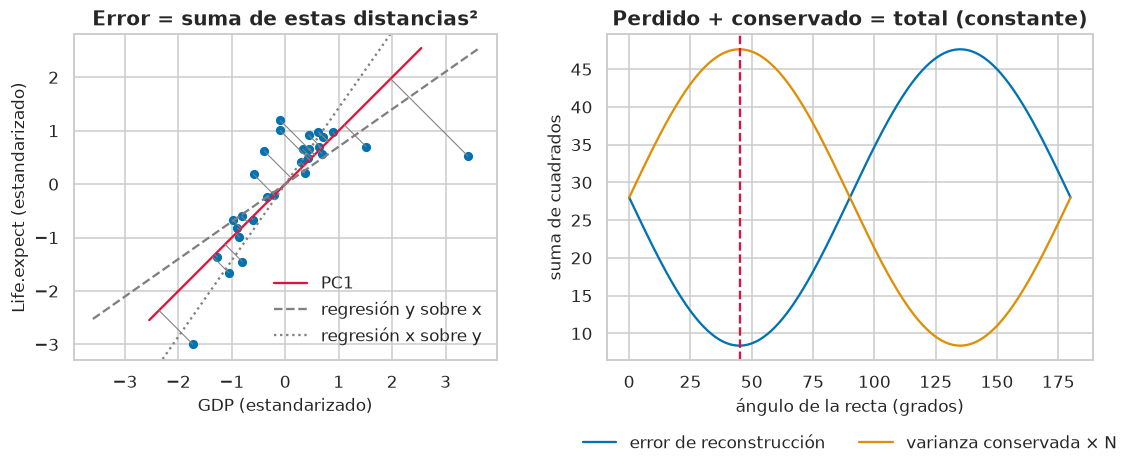

ángulo óptimo: 45.0 grados


In [3]:
# Dos variables estandarizadas para poder dibujar la recta
cols_s1 = ["GDP", "Life.expect"]
Z2_s1 = paises[cols_s1].to_numpy(float)
Z2_s1 = (Z2_s1 - Z2_s1.mean(0)) / Z2_s1.std(0)

thetas = np.linspace(0, np.pi, 361)
dirs = np.c_[np.cos(thetas), np.sin(thetas)]                # una dirección por ángulo
proj = Z2_s1 @ dirs.T                                       # N x 361: coordenada sobre cada recta
var_proj = (proj ** 2).mean(0)                              # varianza de lo que conservo
err_rec = (Z2_s1 ** 2).sum() - (proj ** 2).sum(0)           # lo que pierdo: suma de distancias^2

th_best = thetas[err_rec.argmin()]
v_best = np.array([np.cos(th_best), np.sin(th_best)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.scatter(*Z2_s1.T, s=25)
t = np.linspace(-3.6, 3.6, 2)
ax1.plot(t * v_best[0], t * v_best[1], color="crimson", label="PC1")
foot = (Z2_s1 @ v_best)[:, None] * v_best                   # pie de la perpendicular
for a, b in zip(Z2_s1, foot):
    ax1.plot([a[0], b[0]], [a[1], b[1]], color="gray", lw=0.7)
ax1.set(xlabel="GDP (estandarizado)", ylabel="Life.expect (estandarizado)",
        title="Error = suma de estas distancias²", aspect="equal")
slope_yx = (Z2_s1[:, 0] @ Z2_s1[:, 1]) / (Z2_s1[:, 0] @ Z2_s1[:, 0])   # y sobre x
slope_xy = (Z2_s1[:, 0] @ Z2_s1[:, 1]) / (Z2_s1[:, 1] @ Z2_s1[:, 1])   # x sobre y
ax1.plot(t, slope_yx * t, color="gray", ls="--", label="regresión y sobre x")
ax1.plot(t, t / slope_xy, color="gray", ls=":", label="regresión x sobre y")
ax1.set(ylim=(-3.3, 2.8))
ax1.legend()

ax2.plot(np.degrees(thetas), err_rec, label="error de reconstrucción")
ax2.plot(np.degrees(thetas), (Z2_s1 ** 2).sum() - err_rec, label="varianza conservada × N")
ax2.axvline(np.degrees(th_best), color="crimson", ls="--")
ax2.set(xlabel="ángulo de la recta (grados)", ylabel="suma de cuadrados",
        title="Perdido + conservado = total (constante)")
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2)
plt.tight_layout(); plt.show()
print("ángulo óptimo:", np.degrees(th_best).round(1), "grados")

**Qué mirar.** A la izquierda, además de la recta roja se ven las dos rectas de regresión (punteadas): el PC1 queda **entre** ellas. Los segmentos grises son los $\|x_i-\mathbf{V}\mathbf{V}^Tx_i\|$: la recta roja es la que hace mínima la suma de sus cuadrados. A la derecha, las dos curvas son **espejo**: donde el error es mínimo, la varianza conservada es máxima. Eso es Pitágoras y es la mitad del §2.

> 🔗 **Conexión con la clase 2.** Esto *no* es regresión de `Life.expect` sobre `GDP`. En cuadrados mínimos se mide la distancia **vertical** (el error está en $y$); acá la distancia es **perpendicular** a la recta y no hay variable "respuesta". Con $r\neq0$, las dos coinciden solo si las variables están perfectamente correlacionadas ($|r|=1$).

#### ⚠️ Confusión típica

Creer que PCA es "regresión lineal donde no hay $y$". Cambia la geometría (vertical vs. perpendicular) y por lo tanto el resultado: la recta de regresión de $y$ sobre $x$ y la de $x$ sobre $y$ son distintas entre sí, y el PC1 queda en el medio.

## 2. La solución es la SVD de $\mathbf{X}$

📕 ESL §14.5.1 (la SVD de ec. 14.54 y la propiedad de máxima varianza que ESL cita) · 🔗 clase 3 §4–§6 · 🔗 clase 6 §5 · 📓 `notes/descomposicion-matrices-svd.md`

> **Pregunta guía:** ¿cómo se encuentra el $\mathbf{V}_q$ que resuelve (14.53) sin probar ángulos uno por uno?

#### La idea en criollo

En la clase 3 la SVD te decía que cualquier matriz es **rotar, estirar, rotar**. Aplicada a la matriz de datos, el "estirar" te dice cuánto se extiende la nube en cada eje de una base ortonormal elegida a medida. PCA es leer esa base: el eje más estirado es el PC1, el siguiente más estirado (perpendicular al primero) es el PC2, y así.

> **Dónde se rompe.** Aplicada a una matriz de datos $N\times p$, la SVD no "mueve" la nube. Rota en **dos espacios distintos**: $\mathbf{V}^T$ elige los ejes en el espacio de las variables, $\mathbf{D}$ dice cuánto se extiende la nube en cada uno, y $\mathbf{U}$ ubica a cada país a lo largo de esos ejes. La nube es la que es; la SVD solo te dice **en qué ejes conviene mirarla** para que cada eje cuente su parte de la varianza sin repetir lo del otro.

#### Formalizándolo

**Paso 1: Pitágoras.** Con $H_q=\mathbf{V}_q\mathbf{V}_q^T$ (proyección), para cada punto centrado vale $\|x_i\|^2=\|H_qx_i\|^2+\|(I-H_q)x_i\|^2$, porque lo proyectado y el residuo son perpendiculares. Sumando sobre $i$:

$$\underbrace{\sum_i\|x_i\|^2}_{\text{total, fijo}}=\underbrace{\sum_i\|\mathbf{V}_q^Tx_i\|^2}_{\text{lo que conservo}}+\underbrace{\sum_i\|x_i-H_qx_i\|^2}_{\text{lo que pierdo}}$$

El total no depende de $\mathbf{V}_q$, así que **minimizar lo perdido = maximizar lo conservado**, que es $\sum_i\|\mathbf{V}_q^Tx_i\|^2=\operatorname{tr}(\mathbf{V}_q^T\mathbf{X}^T\mathbf{X}\mathbf{V}_q)$.

**Paso 2: el caso $q=1$ con Lagrange.** Queremos $\max_v\ v^T\mathbf{X}^T\mathbf{X}v$ sujeto a $v^Tv=1$. El lagrangiano $v^T\mathbf{X}^T\mathbf{X}v-\gamma(v^Tv-1)$ (con $\gamma$ el multiplicador que impone $v^Tv=1$) da, al derivar,

$$\mathbf{X}^T\mathbf{X}\,v=\gamma\,v ,$$

o sea que $v$ es un **autovector** de $\mathbf{X}^T\mathbf{X}$, y el valor alcanzado es $v^T\mathbf{X}^T\mathbf{X}v=\gamma\,v^Tv=\gamma$. Para maximizar, el autovalor más grande. Para $q>1$ se repite pidiendo ortogonalidad a los anteriores (ESL lo resume así: $\mathbf{X}v_2$ tiene máxima varianza entre las combinaciones con $v_2\perp v_1$, etc.).

**Paso 3: la SVD ya trae esos autovectores.** Con $\mathbf{X}=\mathbf{U}\mathbf{D}\mathbf{V}^T$ (clase 3, versión *thin*; con $N\ge p$, como en los países; si $N<p$, $\mathbf{V}$ trae solo $N$ columnas útiles):

$$\mathbf{X}^T\mathbf{X}=\mathbf{V}\mathbf{D}^2\mathbf{V}^T$$

Es exactamente la descomposición espectral de la clase 6 §5, con autovalores $d_j^2$ y autovectores $v_j$. Entonces, para cada rango $q$, **$\hat{\mathbf{V}}_q$ son las primeras $q$ columnas de $\mathbf{V}$** (ESL, ec. 14.54 y comentario siguiente).

**Paso 4: qué es cada cosa.**

- **Direcciones** (*loadings*, *componentes* en sklearn): $v_j$, columnas de $\mathbf{V}$. Dicen *con qué receta* se mezclan las variables originales.
- **Scores** (lo que ESL llama *principal components*): las columnas de $\mathbf{U}\mathbf{D}=\mathbf{X}\mathbf{V}$. La coordenada de cada país en el eje $j$ es $x_i^Tv_j=u_{ij}d_j$. Las primeras $q$ columnas son los $\hat\lambda_i$ de (14.52).
- **Varianza** del componente $j$: $\frac1N\|\mathbf{X}v_j\|^2=\frac1N d_j^2\|u_j\|^2=d_j^2/N$. Las varianzas suman $\frac1N\sum_jd_j^2=\frac1N\|\mathbf{X}\|_F^2$ (la norma de Frobenius al cuadrado es la suma de todos los elementos al cuadrado), la varianza total.
- **Error de reconstrucción** con $q$ componentes: $\sum_{j>q}d_j^2$ (lo que dejás afuera). Esto es el teorema de Eckart–Young: la aproximación de rango $q$ de $\mathbf{X}$ por SVD truncada es la mejor posible. Lo usamos como resultado; no lo demostramos acá **(MML / general)**.
- **Cada componente está sin correlacionar con los otros**: $u_j^Tu_k=0$ implica $(\mathbf{X}v_j)^T(\mathbf{X}v_k)=d_jd_k\,u_j^Tu_k=0$. Es lo que ESL, en la introducción de §14.5, resume como "proyecciones mutuamente no correlacionadas y ordenadas por varianza".

> **Convención de este notebook.** En la teoría dividimos por $N$ (como ESL y como la clase 6). `sklearn` divide por $N-1$ (varianza muestral insesgada). Eso cambia un factor común $N/(N-1)$ en **todas** las varianzas: vectores, scores y proporciones de varianza explicada no cambian.

> 🔗 **Conexión con las clases 3 y 6 (cuidado con la notación).** En la clase 3, $\mathbf{D}$ son los **valores singulares** $d_j$ de $\mathbf{X}$. En la clase 6 §5, $\mathbf{D}$ son los **autovalores** de $\hat\Sigma$ y las direcciones se llaman $\mathbf{U}$ (acá son $\mathbf{V}$). La relación es la misma que acá, $\lambda_j=d_j^2/\text{divisor}$, solo que en LDA la matriz es la covarianza de los residuos por clase y el divisor es $N-K$. Misma letra, objetos distintos. Acá siempre $d_j$ singular y $d_j^2/N$ varianza. Y la clase 6 ya usó una versión: el rango reducido de LDA es PCA de los centroides esferizados (cap. 4 §4.3.3), **no** PCA de $\mathbf{X}$.

#### ¿Por qué nos importa?

Porque te da **dos caminos que tienen que dar lo mismo** y es la verificación que conviene hacer siempre: (a) SVD de $\mathbf{X}$ centrada, o (b) autovectores de la matriz de covarianza $\mathbf{X}^T\mathbf{X}/N$. Para el parcial, es la derivación en frío que aparece en el mapa. Para el código, (a) es el camino principal: no forma $\mathbf{X}^T\mathbf{X}$, que **eleva al cuadrado el condicionamiento** (clase 2) y pierde las direcciones de varianza chica.

#### En código: ambos caminos sobre los países estandarizados

Antes de correr PCA estandarizamos (el porqué es el §3; por ahora tomalo como paso previo): `Z` es la $\mathbf{X}$ del texto, centrada y con cada columna dividida por su desvío. Las verificaciones de abajo responden a tres pasos del razonamiento: (1) SVD y autovectores de la covarianza dan lo mismo (Paso 3); (2) los scores son $\mathbf{U}\mathbf{D}$ y están sin correlacionar (Paso 4); (3) lo perdido es $\sum_{j>q}d_j^2$ (Pitágoras, Paso 1).

In [4]:
mu = X_raw.mean(0)
sd = X_raw.std(0)                       # ddof=0, igual que StandardScaler
Z = (X_raw - mu) / sd                   # ← la matriz X centrada y estandarizada

# Camino (a): SVD de Z
U, d, Vt = np.linalg.svd(Z, full_matrices=False)    # Z = U diag(d) Vt  (thin)
V = Vt.T

# Camino (b): autovectores de la covarianza Z'Z/N  (eigh: matriz simétrica)
lam, W = np.linalg.eigh(Z.T @ Z / N)
lam, W = lam[::-1], W[:, ::-1]                      # eigh devuelve orden creciente

print("varianza de cada PC = d²/N  :", (d ** 2 / N).round(3))
print("autovalores de Z'Z/N        :", lam.round(3))
print("direcciones coinciden (salvo signo):", np.allclose(np.abs(V), np.abs(W)))

scores = Z @ V                                       # = U * d
print("scores = U·D = Z·V          :", np.allclose(scores, U * d))
print("scores sin correlacionar    :", np.allclose(np.cov(scores.T, bias=True), np.diag(d ** 2 / N)))

# Pitágoras con q = 2: total = conservado + perdido
q = 2
Zq = scores[:, :q] @ V[:, :q].T                      # reconstrucción de rango 2
print("perdido = Σ_{j>q} d_j²      :", np.isclose(((Z - Zq) ** 2).sum(), (d[q:] ** 2).sum()))
print("total   = Σ d_j²            :", np.isclose((Z ** 2).sum(), (d ** 2).sum()))

varianza de cada PC = d²/N  : [3.227 1.187 1.063 0.77  0.458 0.169 0.126]
autovalores de Z'Z/N        : [3.227 1.187 1.063 0.77  0.458 0.169 0.126]
direcciones coinciden (salvo signo): True
scores = U·D = Z·V          : True
scores sin correlacionar    : True
perdido = Σ_{j>q} d_j²      : True
total   = Σ d_j²            : True


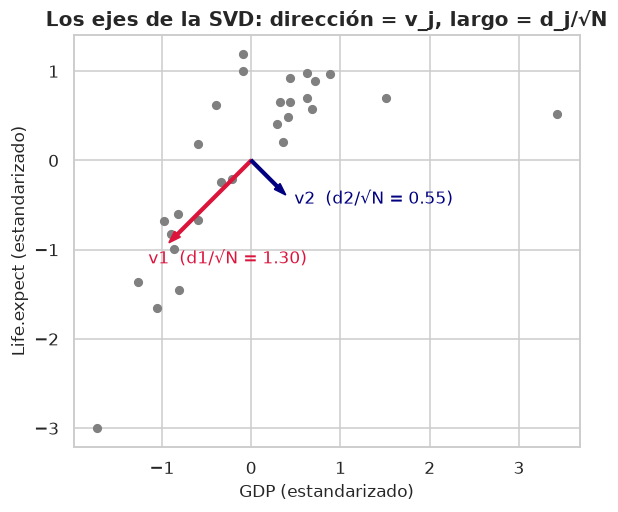

In [5]:
# La SVD "dibujada" con 2 variables: ejes v_j de la nube, escalados por su desvío d_j/√N
U2_s2, d2_s2, Vt2_s2 = np.linalg.svd(Z2_s1, full_matrices=False)
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(*Z2_s1.T, s=25, color="gray")
for j, col in enumerate(["crimson", "navy"]):
    long = d2_s2[j] / np.sqrt(N)
    ax.arrow(0, 0, long * Vt2_s2[j, 0], long * Vt2_s2[j, 1], color=col, width=0.03, length_includes_head=True)
    ax.text(1.25 * long * Vt2_s2[j, 0], 1.25 * long * Vt2_s2[j, 1], f"v{j + 1}  (d{j + 1}/√N = {long:.2f})", color=col)
ax.set(xlabel="GDP (estandarizado)", ylabel="Life.expect (estandarizado)", aspect="equal",
       title="Los ejes de la SVD: dirección = v_j, largo = d_j/√N")
plt.tight_layout(); plt.show()

**Qué mirar.** $v_1$ (rojo) apunta a lo largo de la nube y es **largo** (mucha varianza); $v_2$ (azul) es perpendicular y **corto** (poca). Es la SVD de la clase 3 leída sobre los datos: $\mathbf{V}$ son los ejes, $\mathbf{D}$ los largos, y las coordenadas de cada punto sobre esos ejes están en $\mathbf{U}\mathbf{D}$.

Con las verificaciones hechas, un dato para ubicar los números: como $\mathbf{Z}$ está estandarizada, cada columna tiene varianza $1$, así que la varianza **total** es $p=7$. Si PC1 tiene varianza $\approx 3{,}2$ (con $N$ en vez de $N-1$), explica $3{,}2/7\approx 46\,\%$.

#### ⚠️ Confusión típica

1. **El signo.** Si $v_j$ es solución, $-v_j$ también (misma recta, misma varianza). El signo de cada componente es **arbitrario** y depende del algoritmo. No interpretes "PC1 positivo = rico": interpretá *qué extremos* se oponen.
2. **"Componentes principales" significa dos cosas.** ESL llama así a las columnas de $\mathbf{U}\mathbf{D}$ (coordenadas); `sklearn` llama `components_` a las filas de $\mathbf{V}^T$ (direcciones). Cuando alguien diga "el primer componente", preguntate cuál de los dos es.
3. **Eigen sobre $\mathbf{X}^T\mathbf{X}$ vs. SVD de $\mathbf{X}$.** En exacto son lo mismo (arriba). En punto flotante, $\kappa(\mathbf{X}^T\mathbf{X})=\kappa(\mathbf{X})^2$; por eso se prefiere la SVD (§4).

## 3. Centrar y estandarizar: lo que PCA no perdona

📕 ESL §14.5.1 (solo menciona centrar; la discusión de escalas es **(MML / general)**) · 🔗 clase 4–5 (se estandariza antes de ridge/lasso) · 🔗 clase 6 §5 (invarianza de LDA)

> **Pregunta guía:** ¿qué pasa con los componentes si cambio las unidades de una variable?

#### La idea en criollo

Pedirle a PCA que encuentre "las direcciones donde los datos más varían" sin avisarle en qué unidades está cada variable es como preguntar "¿qué mide más: el ancho de la mesa o el peso de la mesa?". Si medís el ancho en milímetros y el peso en toneladas, gana el ancho por goleada, y no porque importe más sino porque el número es grande.

> **Dónde se rompe.** La analogía sugiere que el problema es solo de unidades distintas. Pero aunque todo esté en la misma unidad, una variable con más dispersión absoluta domina igual. Estandarizar decide algo más fuerte: que **todas las variables pesan lo mismo a priori**.

#### Formalizándolo

- **Centrar es obligatorio.** Sin restar $\bar x$ la solución del §1 deja de valer (el plano pasaría por el origen y no por la nube). Si no centrás, PC1 suele apuntar al centroide.
- **Estandarizar es una decisión.** Dividir cada columna por su desvío $\sigma_j$ hace que la matriz sobre la que se descompone sea la de **correlaciones** y no la de covarianzas: $\tfrac1N\mathbf{Z}^T\mathbf{Z}=R$, con $1$ en la diagonal. Entonces la varianza total es $p$.
- **PCA no es invariante a cambios de escala por variable.** Con una rotación de los datos, los scores no cambian y los ejes rotan con ellos (es *equivariante*); un escalado igual para todas las variables tampoco cambia ejes ni proporciones. Lo que rompe PCA es escalar **cada variable distinto**. **Contraste con LDA** (clase 6 §5): la *regla de clasificación* de LDA es invariante a cualquier $x\to Ax+b$ invertible, porque $\hat\Sigma$ absorbe la transformación en la esferización (los centroides se transforman igual y los priors no cambian); PCA no tiene ese mecanismo, usa directamente las varianzas de los datos. (La invarianza de LDA se rompe con regularización, como RDA, o con $\hat\Sigma$ singular).
- Cuándo **no** estandarizar: cuando todas las variables ya están en la misma unidad con significado comparable. En el ejemplo de los dígitos de ESL los $256$ píxeles están todos en la misma escala; ahí no hay unidades que igualar (esta lectura es mía, ESL no discute el tema).

#### En código: sin estandarizar vs. estandarizado

Hacemos PCA dos veces sobre los países: con los datos solo centrados y con los datos estandarizados.

,% var PC1,peso de Area en PC1
"centrado, Area en km²",0.993,1.000
"centrado, Area en miles de km²",1.000,0.002
estandarizado,0.461,0.125


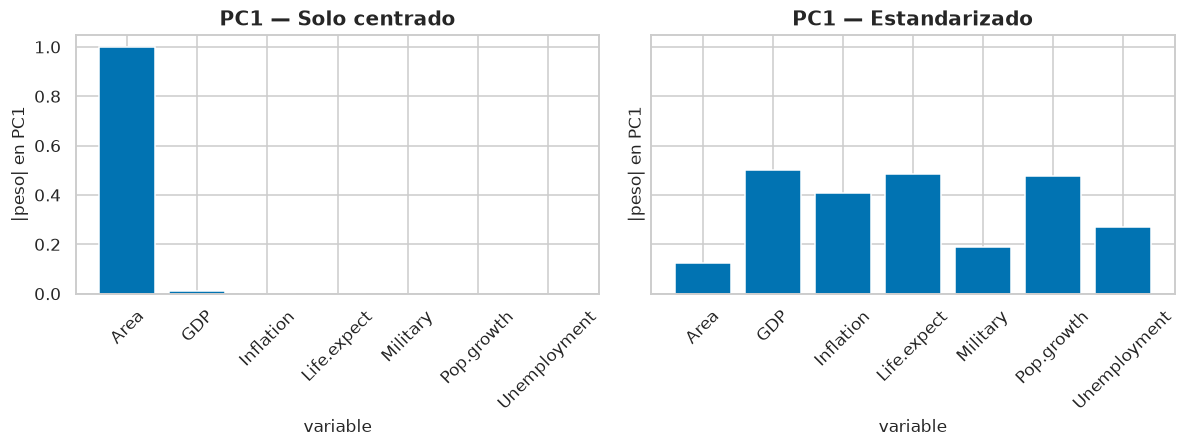

In [6]:
def pca_basico(M):
    # SVD de M ya centrada → (direcciones V, proporción de la varianza total por componente)
    _, d_, Vt_ = np.linalg.svd(M, full_matrices=False)
    return Vt_.T, d_ ** 2 / (d_ ** 2).sum()

V_centrado, prop_centrado = pca_basico(X_raw - mu)      # solo centrado
V_estand, prop_estand = pca_basico(Z)                   # centrado + estandarizado

# ¿y si el área viene en miles de km² en vez de km²?
X_miles = X_raw.copy(); X_miles[:, 0] /= 1000
V_miles, prop_miles = pca_basico(X_miles - X_miles.mean(0))

res_s3 = pd.DataFrame({
    "% var PC1": [prop_centrado[0], prop_miles[0], prop_estand[0]],
    "peso de Area en PC1": [abs(V_centrado[0, 0]), abs(V_miles[0, 0]), abs(V_estand[0, 0])],
}, index=["centrado, Area en km²", "centrado, Area en miles de km²", "estandarizado"]).round(3)
display(res_s3)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, V_, ttl in zip(axes, [V_centrado, V_estand], ["Solo centrado", "Estandarizado"]):
    ax.bar(paises.columns, np.abs(V_[:, 0]))
    ax.set(title=f"PC1 — {ttl}", xlabel="variable", ylabel="|peso| en PC1")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

**Qué mirar.** Sin estandarizar, el PC1 *es* el área: $\approx 99\,\%$ de la varianza y peso $\approx 1$ sobre `Area`. Cambiar km² por miles de km² (mismo dato, otra unidad) **cambia la respuesta**: el peso de `Area` en PC1 cae de $1{,}00$ a $0{,}002$ y el PC1 pasa a ser `GDP` ($\approx 100\,\%$ de la varianza, porque sus miles de dólares pasan a ser lo más grande). Es la prueba de que sin estandarizar el resultado depende de una decisión arbitraria de unidades. Estandarizado, el PC1 reparte peso entre `GDP`, `Life.expect`, `Pop.growth`, `Inflation` y, algo menos, `Unemployment`, y explica $\approx 46\,\%$.

#### ⚠️ Confusión típica

- **Centrar y estandarizar no son lo mismo.** Centrar mueve; estandarizar además escala. `sklearn.decomposition.PCA` **centra solo, no estandariza**: si no usás `StandardScaler` antes, estás en el caso de la izquierda sin saberlo.
- **"Estandarizar siempre" tampoco es la regla.** Es la regla cuando las variables están en unidades distintas, que es el caso del TP. (MML / general)
- **Estandarizar no es gratis**: infla el peso de variables que son casi ruido (varianza chica por una razón que no es informativa). Es una de las razones por las que el resultado hay que *leerlo*, no solo calcularlo.

## 4. PCA a mano vs. scikit-learn

📕 ESL §14.5.1 · 🔗 clase 3 §4–§6

> **Pregunta guía:** ¿qué hay que escribir para tener un PCA propio, y en qué detalles se va a diferenciar de `sklearn` aunque la matemática sea la misma?

#### Qué escribir

Del §2, el algoritmo es corto:

1. Centrar (y, si corresponde, estandarizar) → $\mathbf{Z}$.
2. SVD: $\mathbf{Z}=\mathbf{U}\mathbf{D}\mathbf{V}^T$.
3. Direcciones $=$ columnas de $\mathbf{V}$; scores $=\mathbf{Z}\mathbf{V}_q$; varianza explicada $=d_j^2/(N-1)$ (para comparar con `sklearn`).
4. Fijar una convención de signo.

Lo escribimos dos veces, una por cada camino del §2: **SVD es el principal; `pca_eig` es solo la verificación cruzada** (§2). Y comparamos con `sklearn`.

In [7]:
def fijar_signo(V_):
    # El mayor |peso| de cada dirección queda positivo (la convención que usa sklearn ≥ 1.5)
    idx = np.abs(V_).argmax(0)
    return V_ * np.sign(V_[idx, np.arange(V_.shape[1])])

def pca_svd(M):
    # M: datos ya centrados (N x p). Devuelve (direcciones V, varianza por PC con divisor N-1, como sklearn)
    _, d_, Vt_ = np.linalg.svd(M, full_matrices=False)
    return fijar_signo(Vt_.T), d_ ** 2 / (len(M) - 1)

def pca_eig(M):
    # Mismo resultado por el otro camino: autovectores de la covarianza
    lam_, W_ = np.linalg.eigh(M.T @ M / (len(M) - 1))
    return fijar_signo(W_[:, ::-1]), lam_[::-1]

def transformar(x_nuevo, mu_, sd_, V_, q_):
    # Proyección de puntos (nuevos o no): estandarizar CON LOS PARÁMETROS DEL ENTRENAMIENTO
    return ((x_nuevo - mu_) / sd_) @ V_[:, :q_]

V_svd, var_svd = pca_svd(Z)
V_eig, var_eig = pca_eig(Z)
print("SVD ≡ eigen:", np.allclose(V_svd, V_eig), np.allclose(var_svd, var_eig))

SVD ≡ eigen: True True


In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Z_sk = StandardScaler().fit_transform(X_raw)           # StandardScaler usa ddof=0, igual que Z
pca_sk = PCA().fit(Z_sk)

print("direcciones     :", np.allclose(V_svd.T, pca_sk.components_))
print("varianzas       :", np.allclose(var_svd, pca_sk.explained_variance_))
print("proporciones    :", np.allclose(var_svd / var_svd.sum(), pca_sk.explained_variance_ratio_))
print("scores (todos)  :", np.allclose(Z @ V_svd, pca_sk.transform(Z_sk)))

# La trampa del N vs N-1: la varianza total NO es p
print("\nsuma de varianzas (N-1):", var_svd.sum().round(3), "= p·N/(N-1) =", round(p * N / (N - 1), 3))

direcciones     : True
varianzas       : True
proporciones    : True
scores (todos)  : True

suma de varianzas (N-1): 7.259 = p·N/(N-1) = 7.259


Todo coincide, **incluido el signo**, porque fijamos la misma convención. Sin esa línea habrían coincidido salvo un $\pm1$ por componente (comprobable con `np.abs`).

La última línea es la trampa de este paso: `StandardScaler` divide por $\sigma$ con $N$ y `PCA` calcula varianzas con $N-1$, así que la suma de `explained_variance_` es $7\cdot 28/27\approx 7{,}26$ y no $7$. Las **proporciones** no cambian; los valores absolutos sí. Si en la presentación mostrás varianzas absolutas, aclará cuál usaste.

##### 🏭 Así se hace en la industria

- **`np.linalg.svd`** (lo que hicimos) o `sklearn.decomposition.PCA`: con `svd_solver="auto"` elige el método según el tamaño de los datos y `n_components`; en general SVD, y en versiones recientes un camino por autovalores de la covarianza cuando $N\gg p$ (`covariance_eigh`). Con $N=28$ y $p=7$ usa SVD.
- **`statsmodels.multivariate.pca.PCA`** es otra librería conocida; trae `standardize=True` por defecto, a diferencia de `sklearn`; su `eigenvals` son los $d_j^2$ sin dividir por $N$, así que no se comparan directo con `explained_variance_`. Si el TP pide "otra librería", sirve para comparar. (general)
- Para $p$ enorme y $q$ chico se usan SVD truncadas/aleatorizadas (`svd_solver="randomized"`): calculan solo los $q$ primeros componentes sin descomponer todo.

#### En código: por qué SVD y no eigen de $\mathbf{X}^T\mathbf{X}$

Una demostración de lo que dijimos en el §2 (clase 2: el condicionamiento se eleva al cuadrado).

In [9]:
print("κ(Z)       =", np.linalg.cond(Z).round(2))
print("κ(Z'Z)     =", np.linalg.cond(Z.T @ Z).round(2), "  ≈ κ(Z)² =", (np.linalg.cond(Z) ** 2).round(2))

κ(Z)       = 5.07
κ(Z'Z)     = 25.69   ≈ κ(Z)² = 25.69


Acá los números son chicos y los dos caminos coinciden; con variables casi colineales o mucha más dimensión, $\kappa(\mathbf{Z}^T\mathbf{Z})$ se dispara y el segundo camino pierde los componentes de varianza chica. Para el TP: SVD como camino principal y eigen como verificación. (Con valores singulares casi repetidos los ejes quedan mal definidos y las tres implementaciones pueden diferir; no pasa acá.)

#### ⚠️ Confusión típica

- **Comparar sin fijar el signo** y concluir "mi implementación está mal". Comparen `np.abs(...)` o fijen la misma convención.
- **Comparar `sklearn` sobre datos sin estandarizar** contra tu PCA sobre datos estandarizados (o al revés). Los dos tienen que ver exactamente la misma matriz de entrada.
- **Olvidar que `PCA` ya centra** pero tu función no: si le pasás a la tuya datos sin centrar, no es PCA.

## 5. Leer el resultado: cuántos componentes y qué significan

📕 ESL §14.5.1, ejemplo de los dígitos escritos a mano (comparación con datos aleatorizados) · el resto **(MML / general)**

> **Pregunta guía:** ¿con cuántos componentes me quedo, y cómo pongo un nombre a cada eje?

#### La idea en criollo

Pensá cada componente como un **cajón de varianza**. La varianza total (acá $p=7$) se reparte entre los $p$ cajones y el primero guarda más que el segundo, etcétera. Preguntar "¿cuántos componentes?" es preguntar cuántos cajones necesito abrir para tener "suficiente" de la varianza.

> **Dónde se rompe.** Varianza no es sinónimo de importancia: un cajón con poca varianza puede contener justo la diferencia que te interesa (por ejemplo, la que separa dos clases). PCA no lo sabe, porque nunca vio una $y$.

#### Formalizándolo

- **Varianza explicada del componente $j$:** $d_j^2/\sum_k d_k^2$; acumulada hasta $q$: $\sum_{j\le q}d_j^2/\sum_kd_k^2$. El complemento es el error de reconstrucción relativo.
- **Cuántos conservar.** No hay regla única (general): un umbral de varianza acumulada (80–90 %), el **codo** del *scree plot*, o (si trabajás con correlación) la regla de Kaiser, que mantiene los $\lambda_j>1$ porque cada variable original aporta varianza $1$.
- **Línea base de ESL:** en el ejemplo de los dígitos comparan los valores singulares con los de los **mismos datos con cada columna permutada al azar** — esos datos tienen las mismas varianzas por columna pero ninguna correlación. Con los datos reales hay un decaimiento mucho más abrupto: eso es estructura. Replicamos la idea.
- **Loadings** (los pesos de $v_j$): los más grandes en valor absoluto dicen qué variables construyen el eje. Que dos variables tengan pesos de **mismo signo** en un PC significa que se mueven juntas a lo largo de ese eje.

#### En código: scree plot con línea base aleatoria

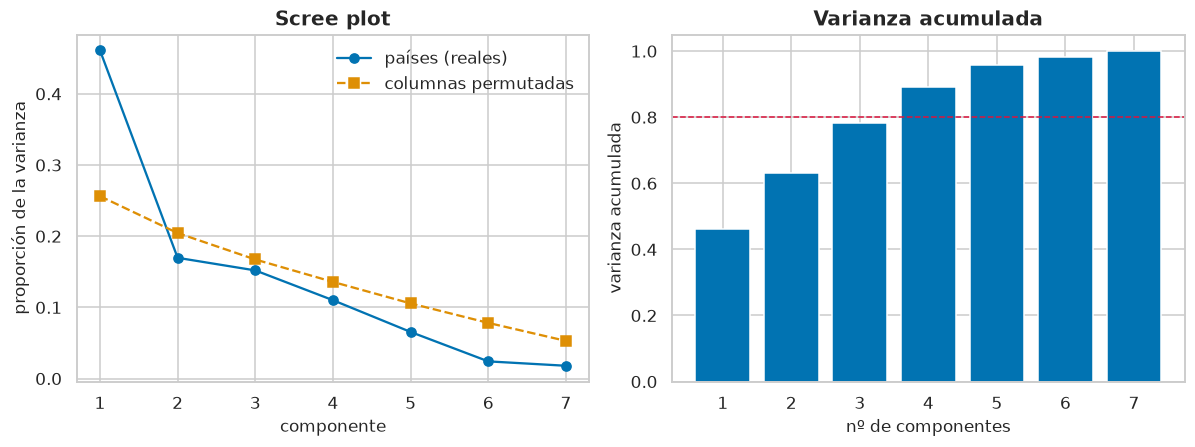

acumulada : [0.461 0.631 0.782 0.893 0.958 0.982 1.   ]
línea base: [0.256 0.204 0.167 0.136 0.106 0.078 0.053]


In [10]:
rng_s5 = np.random.default_rng(0)
prop = var_svd / var_svd.sum()

# Línea base: permuto cada columna por separado → sin correlación entre variables (la proporción esperada solo por azar)
base = np.zeros(p)
n_rep = 300
for _ in range(n_rep):
    Z_perm = np.column_stack([rng_s5.permutation(Z[:, j]) for j in range(p)])
    base += np.linalg.svd(Z_perm, compute_uv=False) ** 2 / (Z_perm ** 2).sum()
base /= n_rep

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
k = np.arange(1, p + 1)
ax1.plot(k, prop, "o-", label="países (reales)")
ax1.plot(k, base, "s--", label="columnas permutadas")
ax1.set(xlabel="componente", ylabel="proporción de la varianza", title="Scree plot")
ax1.legend()
ax2.bar(k, np.cumsum(prop))
ax2.axhline(0.8, color="crimson", ls="--", lw=1)
ax2.set(xlabel="nº de componentes", ylabel="varianza acumulada", title="Varianza acumulada")
plt.tight_layout(); plt.show()
print("acumulada :", np.cumsum(prop).round(3))
print("línea base:", base.round(3))

**Qué mirar.** Solo el PC1 ($\approx 0{,}46$) queda bien por encima de la línea base ($\approx 0{,}26$); desde el PC2 ($\approx 0{,}17$ contra $\approx 0{,}20$) los reales ya no la superan: con $N=28$ y $p=7$ el ruido solo ya produce un PC1 de $\approx 26\,\%$. Por este criterio hay **una** dimensión estructurada; pasar a 2 se justifica por poder dibujar el plano ($\approx 63\,\%$ acumulado; con 3, $\approx 78\,\%$), no porque el PC2 sea "real". Eso hay que decirlo en la presentación.

#### En código: loadings y biplot

,PC1,PC2,PC3
Area,-0.12,-0.17,0.90
GDP,0.50,-0.13,0.08
Inflation,-0.41,-0.37,0.20
Life.expect,0.48,0.27,0.25
Military,-0.19,0.66,0.24
Pop.growth,0.48,0.08,0.16
Unemployment,-0.27,0.55,0.00


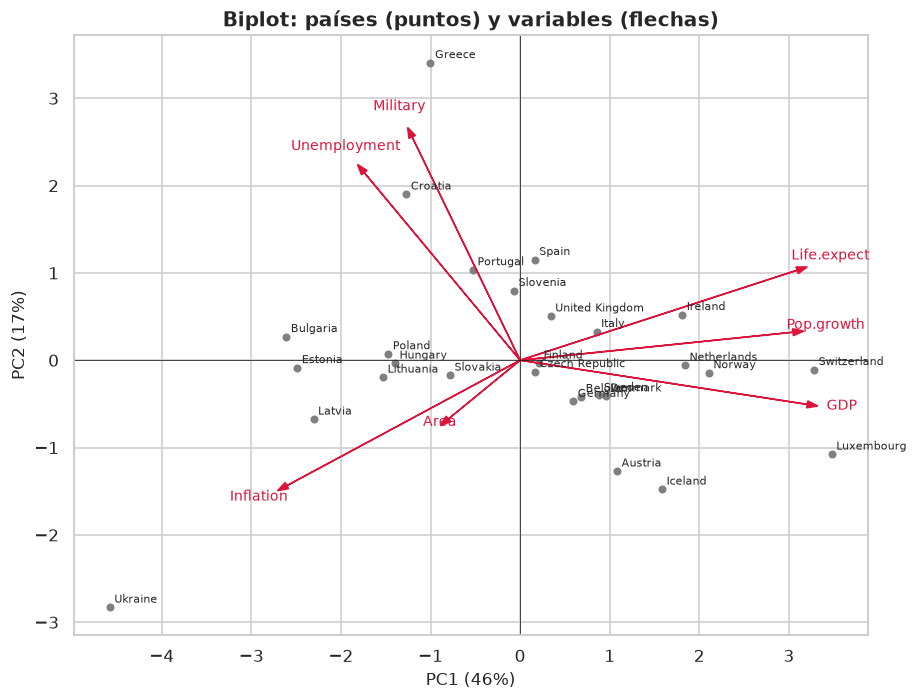

In [11]:
comp = [f"PC{j}" for j in range(1, p + 1)]
cargas = pd.DataFrame(V_svd, index=paises.columns, columns=comp)
display(cargas.iloc[:, :3].round(2))

S = Z @ V_svd                                              # scores
fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.scatter(S[:, 0], S[:, 1], s=18, color="gray")
for nombre, (x_, y_) in zip(paises.index, S[:, :2]):
    ax.annotate(nombre, (x_, y_), fontsize=7.5, xytext=(3, 3), textcoords="offset points")
corr = V_svd * np.sqrt(var_svd)                             # corr(variable, PC) con datos estandarizados
esc = 3.5                                                   # factor visual (las flechas miden ≤ 1)
for j, v in enumerate(paises.columns):
    ax.arrow(0, 0, esc * corr[j, 0], esc * corr[j, 1], color="crimson", head_width=0.08)
    ax.text(esc * 1.12 * corr[j, 0], esc * 1.12 * corr[j, 1], v, color="crimson", fontsize=9, ha="center")
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set(xlabel=f"PC1 ({prop[0]:.0%})", ylabel=f"PC2 ({prop[1]:.0%})", title="Biplot: países (puntos) y variables (flechas)")
plt.tight_layout(); plt.show()

**Cómo se lee el biplot.** Cada flecha es una variable y sus coordenadas son su **correlación** con PC1 y PC2 ($v_{kj}\sqrt{\lambda_j}$, ampliadas por un factor visual). El largo dice cuánto de esa variable se ve en el plano, y flechas que apuntan al mismo lado son variables correlacionadas. Un país está "del lado" de una flecha si tiene un valor alto en esa variable.

**Interpretación (el signo es arbitrario; con nuestra convención, el lado positivo de PC1 es el de `GDP` y el de PC2 es el de `Military`).** En el PC1 se oponen, por un lado, `GDP`, `Life.expect` y `Pop.growth` y, por el otro, `Inflation` y `Unemployment`. Es un eje de **desarrollo económico**: en un extremo Luxemburgo, Suiza y Noruega; en el otro Ucrania, Bulgaria y los países bálticos. El PC2 mezcla `Military` y `Unemployment` con el mismo signo: separa a **Grecia** (gasto militar y desempleo altos, el outlier del plano) y los países del sur (Croacia, Portugal, España), en el lado positivo, de Islandia y Austria en el negativo.

> Esa lectura es **de este dataset**, no de PCA. Otro conjunto de países daría otros ejes.

#### ⚠️ Confusión típica

- **Poner nombre a los ejes como si fueran verdad** ("PC1 es desarrollo"). Es una interpretación razonable de los pesos; no una propiedad que PCA garantice.
- **Confundir correlación entre variables con correlación entre componentes.** Los componentes están sin correlacionar *entre sí*; las variables originales no.
- **Leer distancias del biplot como exactas.** Es una proyección: dos países cercanos en el plano pueden estar lejos en los otros 5 ejes.

## 6. Proyectar países nuevos

📕 ESL §14.5.1 (la fórmula $\hat\lambda_i=\mathbf{V}_q^T(x_i-\bar x)$, ec. 14.52, es para las observaciones; aplicarla a un $x$ nuevo es una extensión directa, **MML / general**) · el diagnóstico de dos preguntas también es **(MML / general)**

> **Pregunta guía:** si aparece un país que no estaba en los 28, ¿dónde cae en el plano y qué tan bien lo representa ese plano?

#### La idea en criollo

El modelo ya está armado: un plano y un punto de apoyo. Un país nuevo es una persona nueva que se para frente a la escultura: no cambiás la cámara, la fotografiás con la misma cámara. Y se pueden preguntar dos cosas distintas: **¿cae lejos del centro de la foto?** y **¿la foto lo muestra bien?** Un punto puede estar muy afuera pero perfectamente representado, o en el centro y muy mal representado.

> **Dónde se rompe.** En la escultura "mal representado" se ve a ojo (queda cortado). En 7 dimensiones no hay nada que ver: es una cuenta, cuánto de ese país queda **fuera** del plano, y el único modo de enterarte es calcularla.

#### Formalizándolo

Con los parámetros del entrenamiento $(\mu,\sigma,\mathbf{V}_q)$:

$$z_{\text{nuevo}}=\frac{x_{\text{nuevo}}-\mu}{\sigma},\qquad \hat\lambda_{\text{nuevo}}=\mathbf{V}_q^Tz_{\text{nuevo}}\quad(\text{sus coordenadas en el plano})$$

Las dos preguntas se contestan con dos números:

- **Posición:** $\hat\lambda_{\text{nuevo}}$ (¿cuán lejos del origen está en el plano, comparado con los 28?).
- **Error de reconstrucción** (a veces SPE): $\|z_{\text{nuevo}}-\mathbf{V}_q\hat\lambda_{\text{nuevo}}\|^2$, la distancia perpendicular al plano, exactamente lo que PCA minimizó para los datos de entrenamiento.

La clave: **estandarizar con $\mu$ y $\sigma$ de los 28**, no con los del país nuevo (ni recalculándolos incluyéndolo). Si no, lo estás midiendo con otra regla.

#### En código: tres países inventados

Son **ficticios** (valores míos, para ilustrar los tres comportamientos posibles): en el TP elijan países reales extremos y citen la fuente, en el mismo año y unidad que el CSV.

coincide con sklearn: True


,PC1,PC2,SPE,SPE / ‖z‖²
Ricolandia,7.09,-1.18,9.11,0.15
Crisistán,-12.83,-3.13,134.37,0.44
Atípico,-1.05,-2.35,34.96,0.84


SPE de los 28 países: mediana 2.13, máximo 12.05; SPE/‖z‖² mediano 0.37


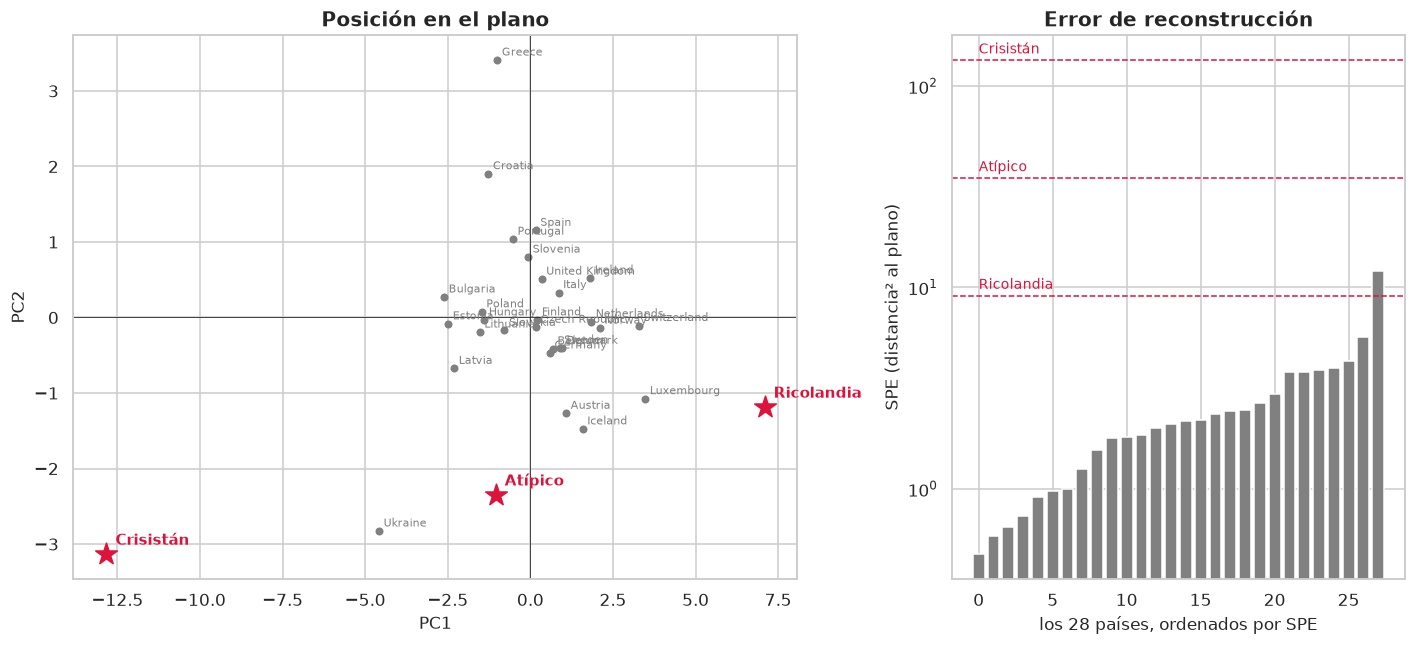

In [12]:
nuevos = pd.DataFrame({
    #               Area    GDP    Infl  Life  Mil  Pop.g  Unemp
    "Ricolandia": [  3000, 120000,  0.5, 84.0, 0.3,  1.5,   2.0],   # muy rico, muy extremo
    "Crisistán":  [250000,   4000, 25.0, 64.0, 3.5, -1.5,  30.0],   # muy pobre, muy extremo
    "Atípico":    [100000,  60000,  9.0, 70.0, 0.0,  1.2,  20.0],   # combina cosas que no van juntas
}, index=paises.columns).T

q_s6 = 2
lam_nuevos = transformar(nuevos.to_numpy(float), mu, sd, V_svd, q_s6)

def spe(M, V_, q_):
    # distancia² al plano de los q_ primeros componentes (M ya estandarizada)
    return ((M - (M @ V_[:, :q_]) @ V_[:, :q_].T) ** 2).sum(1)

spe_train = spe(Z, V_svd, q_s6)
Z_nuevos = (nuevos.to_numpy(float) - mu) / sd
spe_nuevos = spe(Z_nuevos, V_svd, q_s6)

# verificación contra sklearn: transform con el scaler y el PCA ENTRENADOS
sc = StandardScaler().fit(X_raw)
pca2 = PCA(n_components=q_s6).fit(sc.transform(X_raw))
print("coincide con sklearn:", np.allclose(lam_nuevos, pca2.transform(sc.transform(nuevos.to_numpy(float)))))

tabla_s6 = pd.DataFrame(lam_nuevos, index=nuevos.index, columns=["PC1", "PC2"])
tabla_s6["SPE"] = spe_nuevos
tabla_s6["SPE / ‖z‖²"] = spe_nuevos / (Z_nuevos ** 2).sum(1)      # fracción del país que queda fuera del plano
display(tabla_s6.round(2))
print(f"SPE de los 28 países: mediana {np.median(spe_train):.2f}, máximo {spe_train.max():.2f}; SPE/‖z‖² mediano {np.median(spe_train / (Z ** 2).sum(1)):.2f}")

fig, (ax, ax_s) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={"width_ratios": [1.6, 1]})
ax.scatter(S[:, 0], S[:, 1], s=18, color="gray")
for nombre, (x_, y_) in zip(paises.index, S[:, :2]):
    ax.annotate(nombre, (x_, y_), fontsize=7, xytext=(3, 3), textcoords="offset points", color="gray")
ax.scatter(*lam_nuevos.T, marker="*", s=220, color="crimson", zorder=3)
for nombre, (x_, y_) in zip(nuevos.index, lam_nuevos):
    ax.annotate(nombre, (x_, y_), fontsize=10, color="crimson", fontweight="bold", xytext=(6, 6), textcoords="offset points")
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set(xlabel="PC1", ylabel="PC2", title="Posición en el plano")

# Segundo panel: ¿qué tan bien los representa el plano? SPE de los 28 vs. los nuevos (escala log)
ax_s.bar(range(N), np.sort(spe_train), color="gray")
for nombre, v_ in zip(nuevos.index, spe_nuevos):
    ax_s.axhline(v_, color="crimson", ls="--", lw=1)
    ax_s.text(0, v_ * 1.08, nombre, color="crimson", fontsize=9)
ax_s.set(yscale="log", xlabel="los 28 países, ordenados por SPE", ylabel="SPE (distancia² al plano)", title="Error de reconstrucción")
plt.tight_layout(); plt.show()

**Qué mirar.** Tres comportamientos distintos:

- *Ricolandia* cae **lejos sobre el eje PC1** (PC1 $\approx 7$, más allá de Luxemburgo) y su SPE ($\approx 9$) está dentro del rango de los 28 (máximo $\approx 12$), aunque es alto contra la mediana ($\approx 2$). Lo que decide es la **fracción** del país que queda fuera (columna `SPE / ‖z‖²`): para un país tan lejos del centro es chica, así que el plano lo describe bien. Extremo en la misma dirección en la que ya varían los datos.
- *Crisistán* cae todavía más lejos sobre PC1 (más allá de Ucrania). Su SPE absoluto ($\approx 134$, unas 11 veces el máximo de los 28) es enorme, pero la fracción `SPE / ‖z‖²` ($\approx 0{,}44$) es parecida a la de un país típico ($\approx 0{,}37$): el plano captura más de la mitad de su tamaño, como en los demás. El SPE absoluto crece con la distancia al centro (una inflación de $25\,\%$ está a unos $15$ desvíos de la media), así que **hay que leer el SPE y la fracción juntos**.
- *Atípico* cae **dentro de la nube** (sus coordenadas están dentro del rango de los 28), pero el $84\,\%$ de su tamaño queda fuera del plano y su SPE ($\approx 35$) es casi el triple del máximo: tiene un patrón (rico, con inflación y desempleo altos y vida corta) que va en contra de las correlaciones de los 28, y esa parte vive en los componentes que descartamos. Es el único de los tres que el plano **representa mal**.

**La posición en el plano sola engaña** (y el SPE sin su fracción, también): reportá el error de reconstrucción junto con la posición (el panel derecho lo muestra: las líneas rojas por encima de las barras grises son países que el plano no describe bien).

#### ⚠️ Confusión típica

- **Refitear con el país nuevo incluido** o estandarizarlo con su propia media. Proyectar es *aplicar* el modelo; no estimarlo de nuevo.
- **Concluir "es normal porque está cerca del centro"** sin mirar el SPE.
- **Extrapolar con confianza**: un país mucho más allá del rango de los 28 se proyecta sin problema (la cuenta es lineal), pero que la cuenta no falle no significa que el plano siga describiendo bien a esos países.

## 7. PCA dentro de ridge

📕 ESL §3.4.1 (ridge y componentes principales) y §3.5.1 · 🔗 clase 4

> **Pregunta guía:** la clase 4 usó la SVD para ver cómo actúa ridge. ¿Qué tiene eso que ver con PCA?

#### La idea en criollo

Ridge no tiene nada que ver con PCA a primera vista, pero la SVD que usaste en la clase 4 para el estimador ridge *es* la del PCA de las columnas de $\mathbf{X}$. Ridge usa los mismos ejes y los trata distinto: encoge cada coordenada según qué tan estirada está la nube en ese eje. Los ejes anchos casi no se tocan; los angostos se aplastan.

#### Formalizándolo

Con $\mathbf{X}=\mathbf{U}\mathbf{D}\mathbf{V}^T$ (centrada, estandarizada) e $y$ centrada (así el intercepto, que no se penaliza, queda en $\bar y$ y se puede ignorar), el ajuste ridge es

$$\underbrace{\mathbf{X}\hat\beta^{\text{ridge}}}_{\text{ajuste de ridge}}=\sum_{j=1}^{p}u_j\,\frac{d_j^2}{d_j^2+\lambda}\,u_j^Ty .$$

Acá $\lambda\ge0$ es la **penalidad de ridge** (no una varianza). Cada dirección $u_j$ (el $j$-ésimo componente normalizado) se encoge por el factor $d_j^2/(d_j^2+\lambda)\in(0,1)$; ESL §3.4.1 lo dice así: se aplica más encogimiento a las coordenadas de los vectores de la base con $d_j^2$ más chico, y la misma sección liga estos $v_j$ con las *principal component directions*. Un componente con $d_j^2=\lambda$ queda a la mitad; uno con $d_j^2\gg\lambda$ queda casi intacto. Y los grados de libertad efectivos son la suma de esos factores: $\operatorname{df}(\lambda)=\sum_j d_j^2/(d_j^2+\lambda)$.

Esta es la respuesta a "¿dónde está lo supervisado?": en **regresión sobre componentes principales** (PCR) se quedan los primeros $q$ componentes y se tiran los demás con factor $0$; ridge hace lo mismo pero **suave**.

#### En código: ridge a mano sobre los países

Como variable respuesta tomamos `Life.expect` y como predictores las otras 6, todas estandarizadas.

In [13]:
from sklearn.linear_model import Ridge

j_y = list(paises.columns).index("Life.expect")
y_s7 = Z[:, j_y]
X_s7 = np.delete(Z, j_y, axis=1)                       # 6 predictores estandarizados (y centrada)
U7, d7, Vt7 = np.linalg.svd(X_s7, full_matrices=False)

lam_r = 10.0
factor = d7 ** 2 / (d7 ** 2 + lam_r)                   # cuánto se conserva en cada componente

# ridge por la fórmula SVD vs sklearn
beta_svd = Vt7.T @ ((d7 / (d7 ** 2 + lam_r)) * (U7.T @ y_s7))
beta_sk = Ridge(alpha=lam_r, fit_intercept=False).fit(X_s7, y_s7).coef_
print("β ridge: SVD ≡ sklearn:", np.allclose(beta_svd, beta_sk))

# df(λ) = Σ factores = traza de la matriz sombrero
H = X_s7 @ np.linalg.solve(X_s7.T @ X_s7 + lam_r * np.eye(6), X_s7.T)
print("df (de los coeficientes, sin intercepto) = Σ d²/(d²+λ) = traza(H):", np.isclose(factor.sum(), np.trace(H)), "→", factor.sum().round(2), "de 6")

pd.DataFrame({"d_j²": d7 ** 2, "factor d²/(d²+λ)": factor}, index=[f"PC{j}" for j in range(1, 7)]).round(3).T

β ridge: SVD ≡ sklearn: True
df (de los coeficientes, sin intercepto) = Σ d²/(d²+λ) = traza(H): True → 3.89 de 6


,PC1,PC2,PC3,PC4,PC5,PC6
d_j²,71.955,31.805,26.037,21.535,12.659,4.009
factor d²/(d²+λ),0.878,0.761,0.723,0.683,0.559,0.286


**Qué mirar.** Con $\lambda=10$, el primer componente (varianza grande) conserva $\approx 88\,\%$ y el último solo $\approx 29\,\%$: el encogimiento crece a medida que baja la varianza. Es el mecanismo de la clase 4 con nombre y apellido.

> 🔗 **Conexión con la clase 4.** Ridge nunca anula un componente (el factor es $>0$); Lasso (clase 5) sí anula coeficientes. PCR anula **componentes enteros**, no variables originales.

#### ⚠️ Confusión típica

Pensar que PCR "elige variables": descarta *combinaciones* de variables (las de menor varianza), no columnas originales. Y que quedarse con los componentes de mayor varianza no garantiza quedarse con los que predicen mejor $y$: PCA nunca vio la $y$.

## 8. Checklist del TP y guion de 5 minutos

> Esto no resuelve el TP: es el mapa de lo que el notebook ya te dio y de dónde sacar cada figura.

**Pasos mínimos**

1. Cargar, mirar `describe()` y **decidir si se estandariza** (acá sí: unidades distintas). Anotar la decisión y por qué.
2. PCA propio: `pca_svd` (§4) sobre datos centrados/estandarizados. Verificar contra `eig` y contra `sklearn` (mismo input, mismo signo, $N$ vs $N-1$).
3. Varianza explicada y **cuántos componentes** (§5): scree + acumulada; justificar la elección.
4. Interpretar PC1 y PC2 con los loadings y el biplot (§5), nombrándolos como hipótesis.
5. Proyectar **1 o más países reales y extremos** (§6): reportar posición **y** error de reconstrucción.
6. Si se quiere "otra librería": `statsmodels` (§4).

**Figuras que alcanzan para 5 minutos** (una por idea):
(1) scree/acumulada, (2) biplot con países etiquetados, (3) tabla "a mano vs `sklearn`" con `allclose`, (4) los países nuevos sobre el plano.

> El TP lo escribe tu grupo: acá está el *qué* y el *por qué*, no el código para entregar.

**Qué decir y qué no.** La consigna dice que **no hace falta explicar la teoría**. Lo que sí vale la pena decir: qué decisiones tomaron (estandarizar, $q$), qué encontraron (ejes, países extremos), y el límite del resultado (varianza no retenida, ejes como hipótesis).

**Preguntas que probablemente les hagan:** ¿por qué estandarizaron? ¿qué pasa si no? ¿por qué el signo de su PC1 es distinto al de `sklearn`? ¿cuánta información perdieron con 2 componentes? ¿por qué ese país nuevo cae ahí y es confiable?

## 🧵 El hilo conductor

Todo el notebook responde una pregunta: **¿cuál es el mejor plano para mirar la nube?** "Mejor" es "menor error de reconstrucción" (§1), que por Pitágoras es "mayor varianza conservada" (§2), y la respuesta está en la SVD de $\mathbf{X}$ centrada: direcciones en $\mathbf{V}$, coordenadas en $\mathbf{U}\mathbf{D}$, varianza en $d_j^2/N$. Lo que parecía un método nuevo es la **clase 3 aplicada a los datos solos**, sin $y$.

Lo que PCA te da gratis es geometría; lo que no te da gratis son las decisiones: **estandarizar** (§3) cambia el resultado entero, el **signo** es arbitrario, y **cuántos** componentes y **qué significan** son juicios tuyos (§5). Para usarlo con datos nuevos, se proyecta con el modelo entrenado y se mira también cuánto queda fuera del plano (§6).

**Con las clases previas.** *Clase 2:* mínimos cuadrados mide distancia vertical, PCA perpendicular. *Clase 3:* PCA es la SVD; la compresión de rango bajo es el mismo teorema. *Clase 4:* ridge es PCA con encogimiento suave (§7). *Clase 6:* la regla de LDA es invariante a transformaciones lineales invertibles porque esferiza (se demostró allá, acá solo lo contrastamos); PCA no, y por eso se estandariza.

## ✅ Autoevaluación

Hacelas en papel antes de abrir la respuesta.

**1.** Datos ya centrados, $N=4$: $(3,3),\ (-3,-3),\ (1,-1),\ (-1,1)$. Calculá $\mathbf{X}^T\mathbf{X}$, los autovalores, $\mathbf{V}$, los valores singulares, la proporción de varianza que explica el PC1 y el error de reconstrucción con $q=1$.

<details><summary>Respuesta</summary>

$\mathbf{X}^T\mathbf{X}=\begin{pmatrix}20&16\\16&20\end{pmatrix}$ (suma de $x^2$: $9+9+1+1$; suma de $xy$: $9+9-1-1$). Autovalores $20\pm16=36$ y $4$, con autovectores $\tfrac1{\sqrt2}(1,1)$ y $\tfrac1{\sqrt2}(1,-1)$. Valores singulares $d=(6,2)$. PC1 explica $36/40=90\,\%$. Con $q=1$ el error es $d_2^2=4$ (los puntos $(1,-1)$ y $(-1,1)$ quedan en el origen tras proyectar y cada uno aporta $2$). Los scores del PC1 son $(3\sqrt2,-3\sqrt2,0,0)\approx(4{,}24,-4{,}24,0,0)$, salvo el signo. La celda de abajo lo verifica.

</details>

**2.** Expresás `Area` en m² en vez de km², sin estandarizar. ¿Qué le pasa al PC1 y a su % de varianza?

<details><summary>Respuesta</summary>

Multiplicás la columna por $10^6$ y su varianza por $10^{12}$. El PC1 pasa a ser prácticamente el eje `Area` ($\approx 100\,\%$ de la varianza; ya eran $99\,\%$ con km²). Y a la inversa, con miles de km² el PC1 deja de ser `Area` y pasa a ser `GDP` (§3). El resultado depende de las unidades: esa es la razón de estandarizar.

</details>

**3.** ¿Por qué el signo de un componente es arbitrario? ¿Qué no cambia si lo invertís?

<details><summary>Respuesta</summary>

Si $v_j$ minimiza (14.53), $-v_j$ define la misma recta y el mismo error: $H=vv^T$ no cambia. Se invierten los scores del componente, pero no su varianza, la proporción explicada, la reconstrucción ni las distancias entre países en el plano.

</details>

**4.** Para proyectar un país nuevo, ¿con qué media y desvío lo estandarizás?

<details><summary>Respuesta</summary>

Con los $\mu$ y $\sigma$ **de los 28 países de entrenamiento**. Con los suyos propios (o recalculando con él incluido) lo estás midiendo con otra regla y los scores no son comparables con los de los demás.

</details>

**5.** ¿Por qué LDA es invariante a $x\to Ax+b$ y PCA no?

<details><summary>Respuesta</summary>

La *regla de clasificación* de LDA usa $\hat\Sigma$ (esferiza con $\hat\Sigma^{-1/2}$): con $x\to Ax+b$ los centroides pasan a $A\mu_k+b$, $\hat\Sigma$ a $A\hat\Sigma A^T$ y los priors no cambian, así que las distancias de Mahalanobis a cada centroide son las mismas y el $\arg\max$ no cambia (los valores de $\delta_k$ sí cambian, en un término común a todas las clases). PCA descompone directamente $\mathbf{X}^T\mathbf{X}$ sin ese cancelador, así que cambiar la escala de una columna cambia las varianzas y por lo tanto los ejes. Con una rotación de los datos, los scores no cambian y las direcciones rotan (equivariante); lo que lo rompe es escalar cada variable distinto. Ojo: la invarianza de LDA se rompe con regularización (RDA) o con $\hat\Sigma$ singular.

</details>

**6.** $N=28$, $p=7$: ¿cuántos componentes con varianza positiva puede haber como máximo? ¿Y si $N=5$, $p=7$?

<details><summary>Respuesta</summary>

El rango de $\mathbf{X}$ es a lo sumo $\min(N-1,p)$ (el $-1$ viene del centrado: las filas suman cero). Con $N=28,p=7$: hasta $7$. Con $N=5,p=7$: hasta $4$; los otros tres valores singulares son $0$ y esas direcciones son arbitrarias.

</details>

**7.** Un país nuevo cae justo en el origen del plano de los dos primeros componentes. ¿Se lo puede considerar "típico"?

<details><summary>Respuesta</summary>

No necesariamente. El plano muestra solo dos de siete dimensiones; puede tener un error de reconstrucción (SPE) alto. Es el caso *Atípico* del §6: bien centrado en el plano pero con un patrón que va contra las correlaciones de los datos de entrenamiento.

</details>

**8.** En ridge, ¿qué factor multiplica a un componente con $d_j^2=\lambda$? ¿Y cuántos grados de libertad tiene ridge si $\lambda\to\infty$?

<details><summary>Respuesta</summary>

Con $d_j^2=\lambda$ (la penalidad igual a ese $d_j^2$) el factor es $d_j^2/(d_j^2+\lambda)=1/2$. Si $\lambda\to\infty$ todos los factores $\to0$: solo queda el intercepto (los grados de libertad de los coeficientes tienden a $0$).

</details>

**9.** PCA y regresión lineal sobre dos variables $x,y$ estandarizadas con correlación $r\neq0$: ¿cuándo coinciden la recta de regresión de $y$ sobre $x$ y el PC1?

<details><summary>Respuesta</summary>

Con datos estandarizados, la recta de regresión tiene pendiente $r$ y el PC1 tiene pendiente $\pm1$ (siempre a $45^\circ$ si $r\neq0$). Coinciden solo cuando $|r|=1$. Para $|r|<1$ el PC1 queda entre la regresión de $y$ sobre $x$ y la de $x$ sobre $y$.

</details>

#### Verificá el ejercicio 1

In [14]:
X_ej = np.array([[3, 3], [-3, -3], [1, -1], [-1, 1]], float)
U_ej, d_ej, Vt_ej = np.linalg.svd(X_ej, full_matrices=False)
print("X'X =\n", X_ej.T @ X_ej)
print("d =", d_ej, "  % PC1 =", (d_ej ** 2 / (d_ej ** 2).sum())[0])
print("scores PC1 =", (X_ej @ Vt_ej.T)[:, 0].round(3), "  error q=1 =", d_ej[1] ** 2)

X'X =
 [[20. 16.]
 [16. 20.]]
d = [6. 2.]   % PC1 = 0.9
scores PC1 = [-4.243  4.243 -0.     0.   ]   error q=1 = 4.0
